In [ ]:
from trainer_tools.all import *
from graph_attention.models.attn_resnet import AttnResNet
from graph_attention.data import *
configure_logging()

<RootLogger root (INFO)>

In [ ]:
ds = get_dataset("imagenette", root='../data', train=True)
val_ds = get_dataset("imagenette", root='../data', train=False)
dl_kwargs = dict(shuffle=True, num_workers=6, persistent_workers=True)
train_loader = DataLoader(ds, batch_size=128, **dl_kwargs)
val_loader = DataLoader(val_ds, batch_size=256, **dl_kwargs)

In [ ]:
model = AttnResNet.load_from_timm("resnet18")

Fetching pretrained weights for resnet18...
00:06:24 [INFO] timm.models._builder: Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)
00:06:25 [INFO] timm.models._hub: [timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


In [ ]:
model.fc = nn.Linear(model.fc.in_features, len(ds.classes))

In [ ]:
epochs = 5
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs)
trainer = Trainer(
    epochs=epochs,
    train_dl=train_loader,
    valid_dl=val_loader,
    model=model,
    optim=optim,
    hooks=[CheckpointHook(save_dir="./checkpoints"), 
        MetricsHook(metrics=[Accuracy(), Loss(), LRStats()], config={}), ProgressBarHook(), LRSchedulerHook(sched)],
    loss_func=nn.CrossEntropyLoss(),
)

In [ ]:
trainer.fit()

Epoch:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 1/5 [Valid]:   0%|          | 0/16 [00:00<?, ?it/s]

00:06:48 [INFO] trainer_tools.hooks.metrics.metrics_hook: Epoch 1/5 | lr: 0.001 | train_accuracy: 0.917 | train_loss: 0.325 | valid_accuracy: 0.952 | valid_loss: 0.183


Epoch 2/5 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]

...

Epoch 4/5 [Valid]:   0%|          | 0/16 [00:00<?, ?it/s]

00:07:49 [INFO] trainer_tools.hooks.metrics.metrics_hook: Epoch 4/5 | lr: 0.001 | train_accuracy: 0.944 | train_loss: 0.190 | valid_accuracy: 0.976 | valid_loss: 0.083


Epoch 5/5 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 5/5 [Valid]:   0%|          | 0/16 [00:00<?, ?it/s]

00:08:10 [INFO] trainer_tools.hooks.metrics.metrics_hook: Epoch 5/5 | lr: 0.001 | train_accuracy: 0.947 | train_loss: 0.168 | valid_accuracy: 0.975 | valid_loss: 0.080
00:08:10 [INFO] trainer_tools.hooks.checkpoint: Saved checkpoint: checkpoints/model_final.pt
00:08:10 [INFO] trainer_tools.checkpoint: Saved model to checkpoints/model.pt


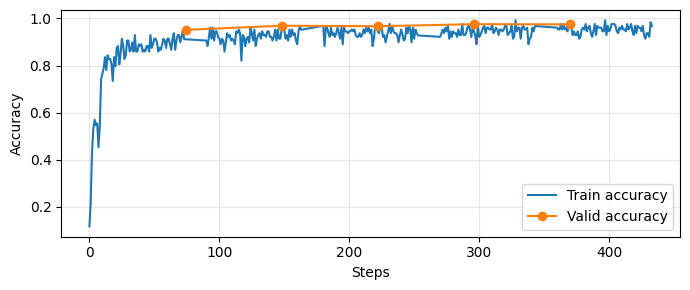

In [ ]:
trainer.get_hook(MetricsHook).plot(metrics=["accuracy"])

In [ ]:
def accuracy(logits, targets):
    preds = logits.argmax(dim=-1)
    return (preds == targets).float().mean()

evaluate(model, val_loader, accuracy)

0.9747770428657532